# FAILSAFE — Student At-Risk Prediction System
## Phase 1 · Imports and Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
df = pd.read_csv('student-mat.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Class distribution:
  Safe (0)    : 265 students (67.1%)
  At-risk (1) : 130 students (32.9%)


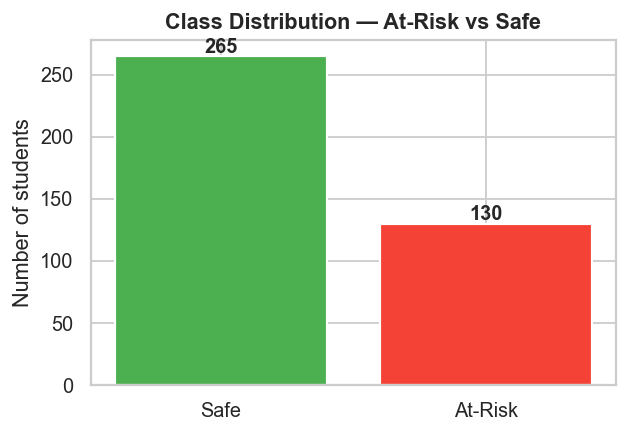

In [2]:
df['at_risk'] = (df['G3'] < 10).astype(int)

counts = df['at_risk'].value_counts()
print('Class distribution:')
print(f'  Safe (0)    : {counts[0]} students ({counts[0]/len(df):.1%})')
print(f'  At-risk (1) : {counts[1]} students ({counts[1]/len(df):.1%})')
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['Safe', 'At-Risk'], [counts[0], counts[1]],
       color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.2)
ax.set_title('Class Distribution — At-Risk vs Safe', fontweight='bold')
ax.set_ylabel('Number of students')
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 3, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

In [3]:
df_encoded = pd.get_dummies(df)
df_encoded = df_encoded.drop(columns=['G1', 'G2', 'G3'])
print(f'Original columns : {df.shape[1]}')
print(f'After encoding   : {df_encoded.shape[1]}  (includes at_risk target)')

Original columns : 34
After encoding   : 57  (includes at_risk target)


## Phase 2 · Model Training (XGBoost)

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.utils import class_weight
from xgboost import XGBClassifier
X = df_encoded.drop(columns=['at_risk'])
y = df_encoded['at_risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape}  — at-risk rate: {y_train.mean():.1%}')
print(f'Test  : {X_test.shape}   — at-risk rate: {y_test.mean():.1%}')

Train : (316, 56)  — at-risk rate: 32.9%
Test  : (79, 56)   — at-risk rate: 32.9%


In [5]:
sample_weights = class_weight.compute_sample_weight('balanced', y_train)
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2,
    random_state=42,
    eval_metric='logloss',
)
model.fit(X_train, y_train, sample_weight=sample_weights)
print('Model trained successfully')

Model trained successfully


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    model, X, y,
    cv=cv,
    scoring=['accuracy', 'f1', 'roc_auc'],
    return_train_score=False,
)
print('── 5-Fold Stratified Cross-Validation ──')
print(f"  Accuracy  : {cv_results['test_accuracy'].mean():.4f}  ± {cv_results['test_accuracy'].std():.4f}")
print(f"  F1 Score  : {cv_results['test_f1'].mean():.4f}  ± {cv_results['test_f1'].std():.4f}")
print(f"  ROC-AUC   : {cv_results['test_roc_auc'].mean():.4f}  ± {cv_results['test_roc_auc'].std():.4f}")
print()
print('Low std deviation = model is stable across different data splits')

── 5-Fold Stratified Cross-Validation ──
  Accuracy  : 0.6658  ± 0.0581
  F1 Score  : 0.4890  ± 0.1043
  ROC-AUC   : 0.6772  ± 0.0753

Low std deviation = model is stable across different data splits


── Hold-out Test Set Performance ──
  Accuracy  : 0.6582
  ROC-AUC   : 0.7068

              precision    recall  f1-score   support

        Safe       0.77      0.70      0.73        53
     At-Risk       0.48      0.58      0.53        26

    accuracy                           0.66        79
   macro avg       0.63      0.64      0.63        79
weighted avg       0.68      0.66      0.66        79



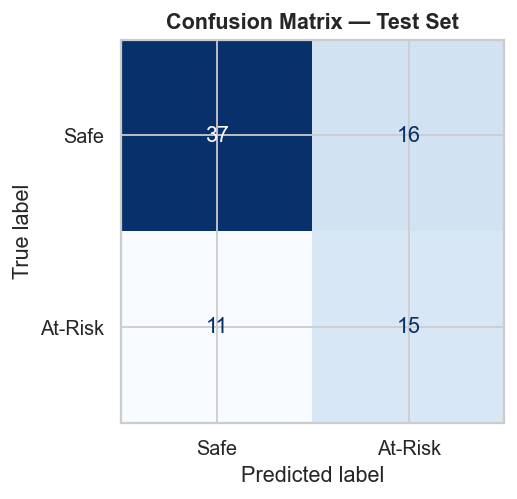

True Positives  (correctly caught at-risk) : 15
False Negatives (missed at-risk students)  : 11  ← most important to minimise
False Positives (safe flagged as at-risk)  : 16
True Negatives  (correctly safe)           : 37


In [7]:
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print('── Hold-out Test Set Performance ──')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Safe', 'At-Risk']))
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'At-Risk'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (correctly caught at-risk) : {tp}')
print(f'False Negatives (missed at-risk students)  : {fn}  ← most important to minimise')
print(f'False Positives (safe flagged as at-risk)  : {fp}')
print(f'True Negatives  (correctly safe)           : {tn}')

In [8]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('model.pkl saved')

model.pkl saved


## Phase 3 · SHAP Analysis — Explainable AI

In [9]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values shape: {shap_values.shape}')
print(f'Base value (expected model output): {explainer.expected_value:.4f}')

SHAP values shape: (79, 56)
Base value (expected model output): 1.0443


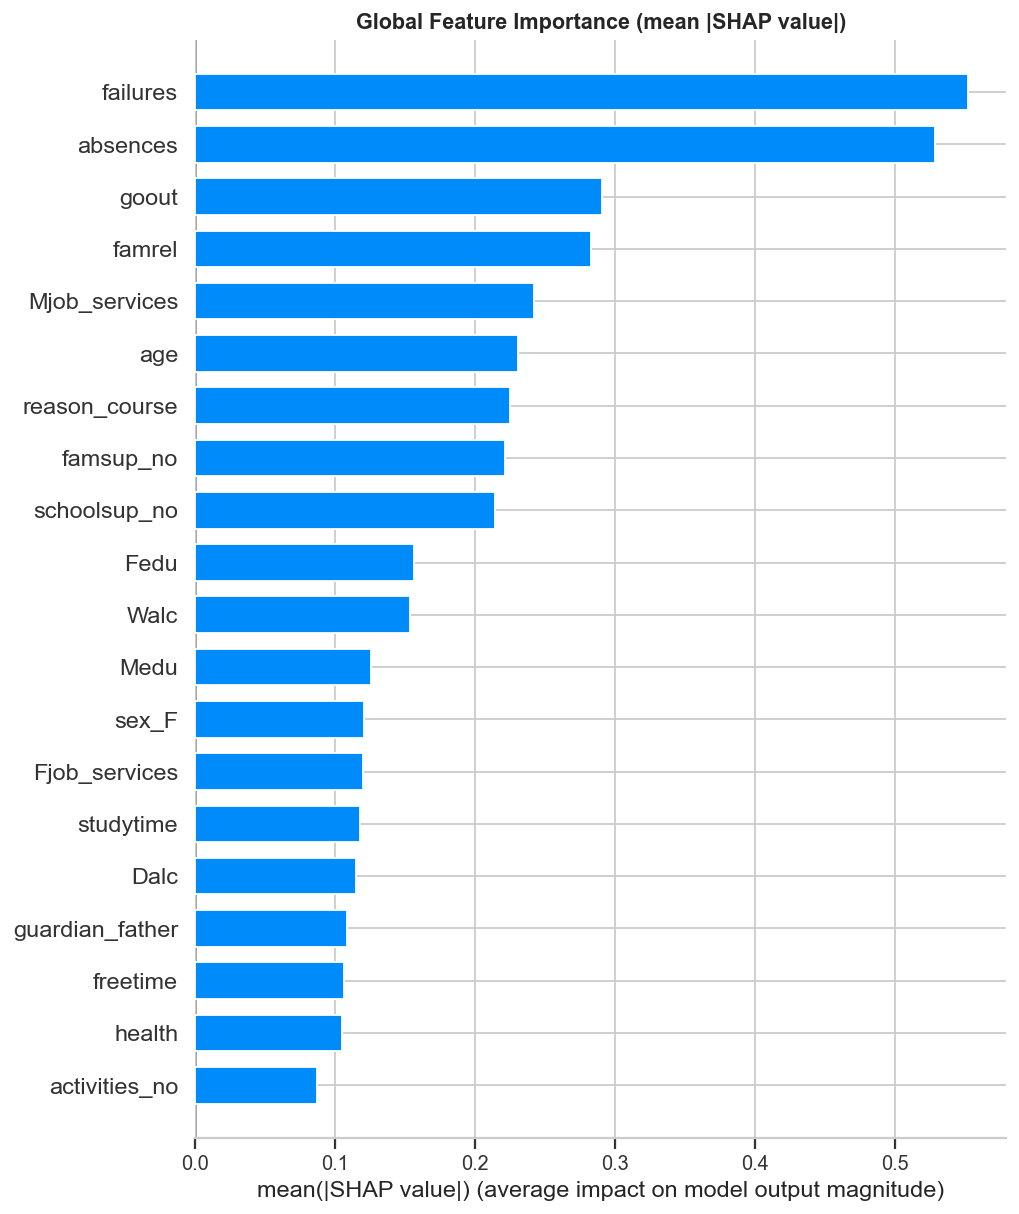

Saved: shap_summary_bar.png


In [10]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Global Feature Importance (mean |SHAP value|)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_summary_bar.png')

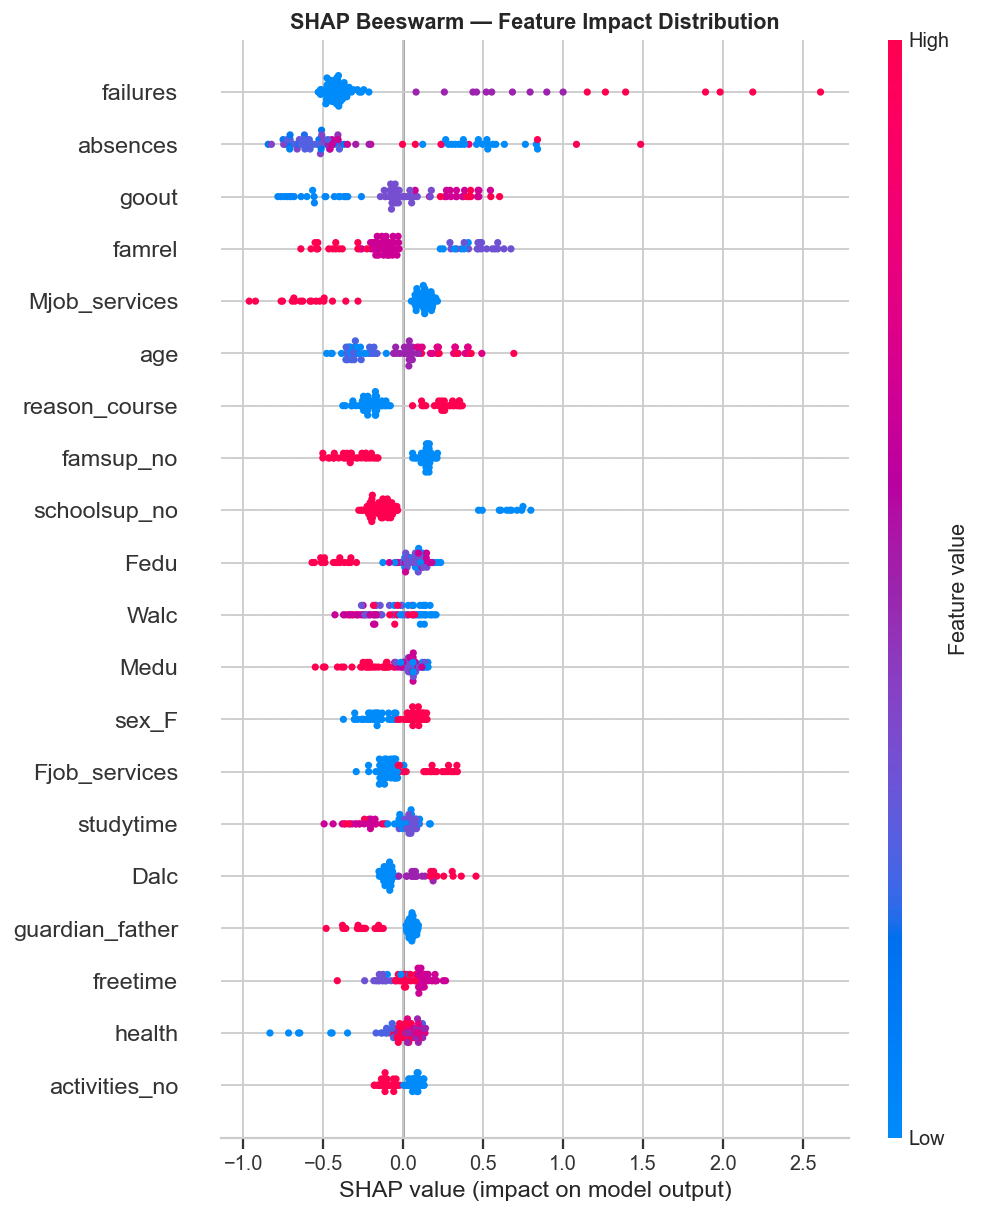

Saved: shap_beeswarm.png


In [11]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm — Feature Impact Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_beeswarm.png')

Student 0 — Predicted risk probability: 92.9000015258789%



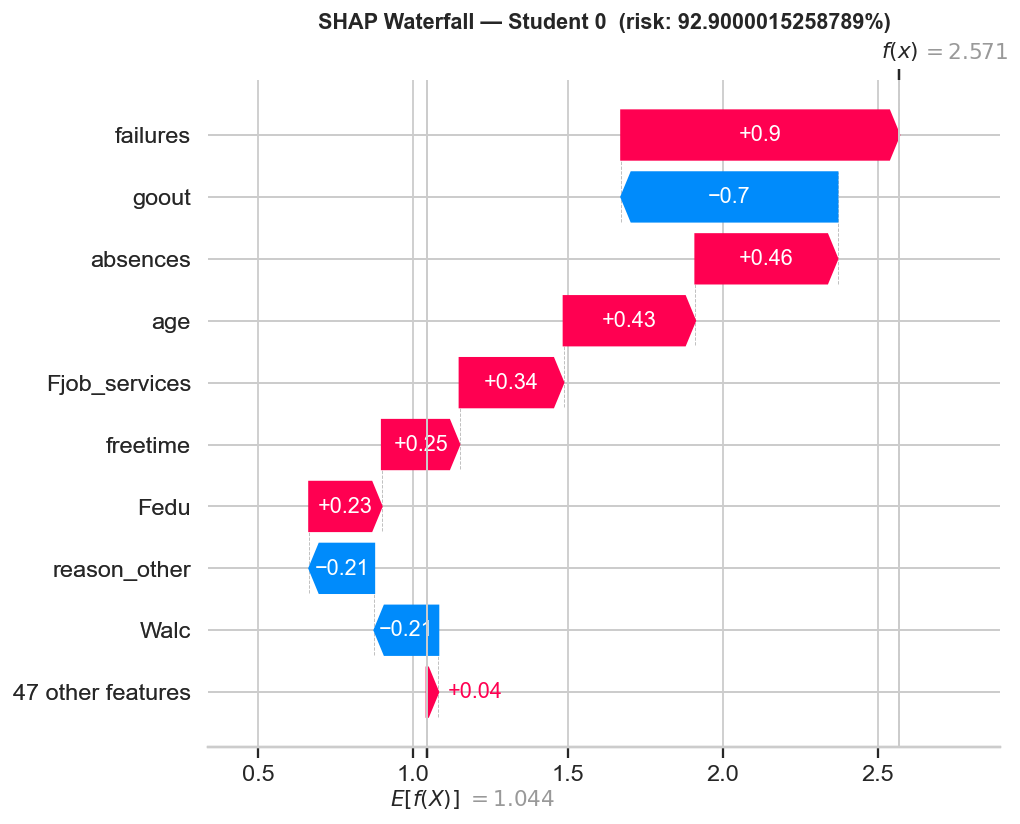

Saved: shap_waterfall_student_0.png


In [12]:
student_idx = 0
risk_pct = round(model.predict_proba(X_test.iloc[[student_idx]])[0][1] * 100, 1)
print(f'Student {student_idx} — Predicted risk probability: {risk_pct}%')
print()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        feature_names=X_test.columns.tolist(),
    ),
    show=False,
)
plt.title(f'SHAP Waterfall — Student {student_idx}  (risk: {risk_pct}%)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_waterfall_student_{student_idx}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: shap_waterfall_student_{student_idx}.png')

Top risk feature: failures


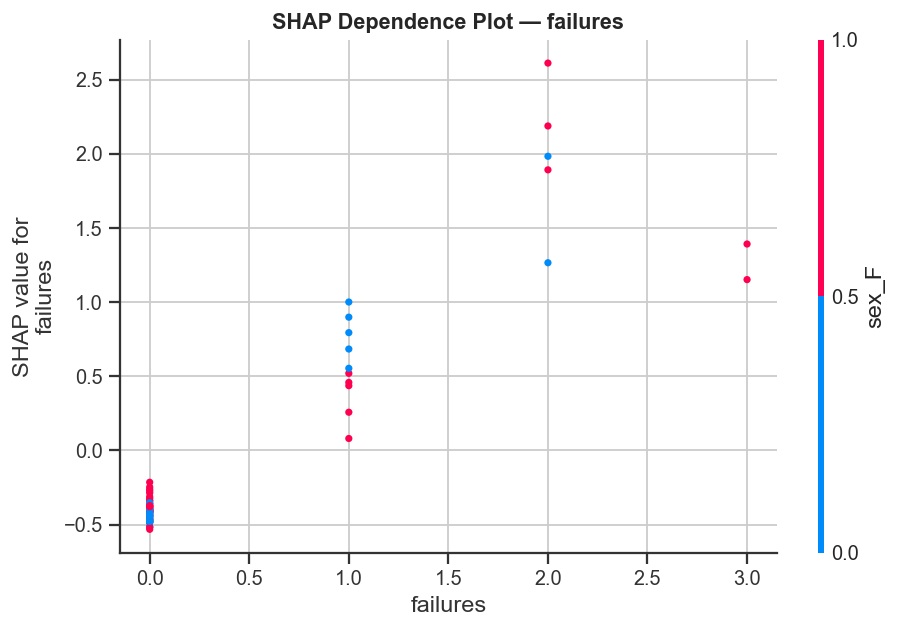

Saved: shap_dependence_failures.png


In [13]:
top_feature = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).idxmax()
print(f'Top risk feature: {top_feature}')
shap.dependence_plot(top_feature, shap_values, X_test, show=False)
plt.title(f'SHAP Dependence Plot — {top_feature}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_dependence_{top_feature}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: shap_dependence_{top_feature}.png')

## Phase 4 · Intervention Generation

In [14]:
INTERVENTION_PRIORITY = {
    'failures':  5,
    'absences':  4,
    'studytime': 3,
    'Dalc':      2,
    'Walc':      2,
    'goout':     2,
    'health':    1,
    'famsup':    1,
    'schoolsup': 1,
    'freetime':  1,
}
INTERVENTION_MAP = {
    'absences':  'Attendance monitoring required — extra classes recommended',
    'failures':  'Previous failure history — counselling session recommended',
    'goout':     'Social activity affecting studies — time management counselling recommended',
    'famsup':    'Lack of family support — parent meeting recommended',
    'schoolsup': 'No school support enrolled — refer to support and scholarship program',
    'studytime': 'Low study time — structured study schedule recommended',
    'health':    'Health issues detected — medical counselling recommended',
    'Dalc':      'Alcohol consumption concern — behavioral counselling recommended',
    'Walc':      'Alcohol consumption concern — behavioral counselling recommended',
    'freetime':  'Excess free time — extracurricular activities recommended',
}
def generate_interventions(shap_vals, feature_names: list) -> list:
    """
    Return a prioritised, deduplicated list of intervention dicts for one student.
    Only positive SHAP values (features pushing toward at-risk) are included.
    """
    shap_dict = dict(zip(feature_names, shap_vals))
    risk_drivers = {k: v for k, v in shap_dict.items() if v > 0}
    top_features = sorted(risk_drivers.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

    seen = set()
    interventions = []

    for feature, shap_value in top_features:
        matched_key = next((k for k in INTERVENTION_MAP if k in feature), None)
        text = (INTERVENTION_MAP[matched_key] if matched_key
                else f"Review factor '{feature}' — faculty attention needed")

        if text not in seen:
            seen.add(text)
            priority = max(
                (INTERVENTION_PRIORITY.get(k, 0) for k in INTERVENTION_PRIORITY if k in feature),
                default=0,
            )
            interventions.append({
                'intervention': text,
                'shap_impact': round(float(shap_value), 4),
                'feature': feature,
                'priority': priority,
            })

    interventions.sort(key=lambda x: (-x['priority'], -abs(x['shap_impact'])))
    return interventions


print('Intervention engine ready')

Intervention engine ready


In [15]:
feature_names = X_test.columns.tolist()
results = []

for i in range(len(X_test)):
    risk_prob = float(model.predict_proba(X_test.iloc[[i]])[0][1])
    risk_label = 'YES' if risk_prob >= 0.5 else 'NO'
    risk_level = 'HIGH' if risk_prob >= 0.70 else ('MEDIUM' if risk_prob >= 0.40 else 'LOW')
    plan = generate_interventions(shap_values[i], feature_names)

    results.append({
        'student_index': i,
        'at_risk': risk_label,
        'risk_level': risk_level,
        'risk_probability_%': round(risk_prob * 100, 2),
        'interventions': ' | '.join(p['intervention'] for p in plan),
    })

results_df = pd.DataFrame(results)
print('── Intervention Report Summary ──')
print(f'  Total students : {len(results_df)}')
print(f'  At-risk (YES)  : {(results_df["at_risk"] == "YES").sum()}')
print(f'  HIGH risk      : {(results_df["risk_level"] == "HIGH").sum()}')
print(f'  MEDIUM risk    : {(results_df["risk_level"] == "MEDIUM").sum()}')
print(f'  LOW risk       : {(results_df["risk_level"] == "LOW").sum()}')
print()
results_df.head()

── Intervention Report Summary ──
  Total students : 79
  At-risk (YES)  : 31
  HIGH risk      : 18
  MEDIUM risk    : 22
  LOW risk       : 39



,student_index,at_risk,risk_level,risk_probability_%,interventions
0,0,YES,HIGH,92.89,Previous failure history — counselling session...
1,1,NO,LOW,17.38,Social activity affecting studies — time manag...
2,2,NO,LOW,22.63,Alcohol consumption concern — behavioral couns...
3,3,YES,MEDIUM,58.94,Previous failure history — counselling session...
4,4,YES,MEDIUM,56.52,Social activity affecting studies — time manag...


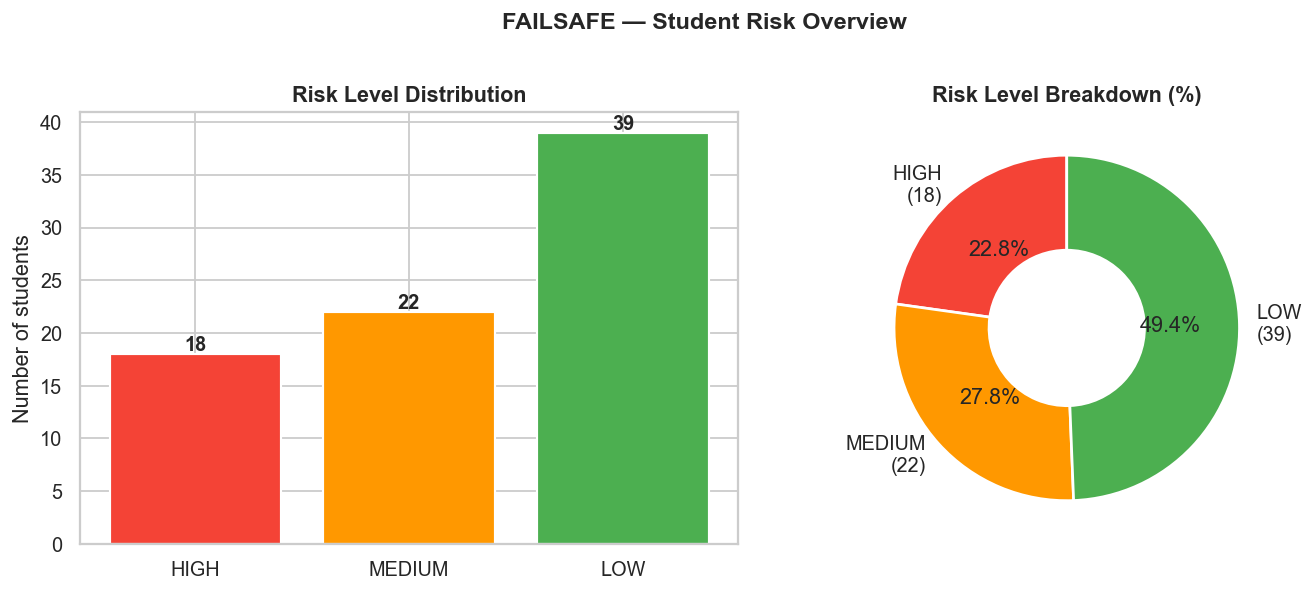

Saved: risk_distribution.png


In [16]:
level_counts = results_df['risk_level'].value_counts().reindex(['HIGH', 'MEDIUM', 'LOW'], fill_value=0)
colours = {'HIGH': '#F44336', 'MEDIUM': '#FF9800', 'LOW': '#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(level_counts.index, level_counts.values,
            color=[colours[l] for l in level_counts.index],
            edgecolor='white', linewidth=1.2)
axes[0].set_title('Risk Level Distribution', fontweight='bold')
axes[0].set_ylabel('Number of students')
for i, v in enumerate(level_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=11, fontweight='bold')

wedge_sizes = level_counts.values
labels = [f'{l}\n({v})' for l, v in zip(level_counts.index, wedge_sizes)]
axes[1].pie(wedge_sizes, labels=labels,
            colors=[colours[l] for l in level_counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
axes[1].set_title('Risk Level Breakdown (%)', fontweight='bold')

plt.suptitle('FAILSAFE — Student Risk Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: risk_distribution.png')

In [17]:
results_df.to_csv('intervention_report.csv', index=False)
print('Saved: intervention_report.csv')
print()
print('── Files generated this session ──')
for fname in [
    'class_distribution.png',
    'confusion_matrix.png',
    'shap_summary_bar.png',
    'shap_beeswarm.png',
    f'shap_waterfall_student_0.png',
    'shap_dependence_<top_feature>.png',
    'risk_distribution.png',
    'intervention_report.csv',
    'model.pkl',
]:
    print(f'  {fname}')

Saved: intervention_report.csv

── Files generated this session ──
  class_distribution.png
  confusion_matrix.png
  shap_summary_bar.png
  shap_beeswarm.png
  shap_waterfall_student_0.png
  shap_dependence_<top_feature>.png
  risk_distribution.png
  intervention_report.csv
  model.pkl
